In [1]:
import random
import time
import heapq
from collections import deque

import pandas as pd
from IPython.display import clear_output

import matplotlib.pyplot as plt

In [2]:
def create_grid(size):
    grid = [["." for _ in range(size)] for _ in range(size)]

    grid[0][0] = "S"
    grid[size - 1][size - 1] = "G"

    for i in range(size):
        for j in range(size):
            if grid[i][j] == ".":
                r = random.random()

                if r < 0.1:
                    grid[i][j] = "#"
                elif r < 0.15:
                    grid[i][j] = "~"
                elif r < 0.2:
                    grid[i][j] = "X"

    return grid

grid = create_grid(8)
grid

[['S', '.', '.', '.', '.', '~', '.', '#'],
 ['.', '#', '.', '~', '.', '.', '#', '.'],
 ['.', '.', '.', '.', '.', '.', '.', '.'],
 ['#', '.', '.', '~', '.', '#', '.', '#'],
 ['.', '.', '#', '.', '.', '.', '.', '.'],
 ['.', '.', '.', '.', '.', '.', '.', '~'],
 ['.', '#', '#', '.', '.', '~', '.', '.'],
 ['.', 'X', '#', '.', '.', '.', '.', 'G']]

In [3]:
def print_grid(grid):
    for row in grid:
        print(" ".join(row))
print_grid(grid)


S . . . . ~ . #
. # . ~ . . # .
. . . . . . . .
# . . ~ . # . #
. . # . . . . .
. . . . . . . ~
. # # . . ~ . .
. X # . . . . G


In [4]:
def show_grid_table(grid):
    return pd.DataFrame(grid)

show_grid_table(grid)

,0,1,2,3,4,5,6,7
0,S,.,.,.,.,~,.,#
1,.,#,.,~,.,.,#,.
2,.,.,.,.,.,.,.,.
3,#,.,.,~,.,#,.,#
4,.,.,#,.,.,.,.,.
5,.,.,.,.,.,.,.,~
6,.,#,#,.,.,~,.,.
7,.,X,#,.,.,.,.,G


In [5]:
def lets_moves(grid, pos, block_all=True):
    row, col = pos
    moves = []

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right

    for dr, dc in directions:
        nr = row + dr
        nc = col + dc

        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]):
            cell = grid[nr][nc]

            # Random, DFS, BFS: treat #, ~, X as blocked
            if block_all:
                if cell not in ["#", "~", "X"]:
                    moves.append((nr, nc))

            # Dijkstra and A*: only # is fully blocked
            else:
                if cell != "#":
                    moves.append((nr, nc))

    return moves

In [6]:
start = (0, 0)
lets_moves(grid, start)

[(1, 0), (0, 1)]

In [7]:
def random_agent(grid):
    start = (0, 0)
    goal = (len(grid) - 1, len(grid[0]) - 1)

    pos = start
    path = [pos]
    steps = 0

    while pos != goal and steps < 3000:
        moves = lets_moves(grid, pos, block_all=True)

        if not moves:
            break

        pos = random.choice(moves)
        path.append(pos)
        steps += 1

    return path, path, steps, pos == goal

In [8]:
path, visited, steps, success = random_agent(grid)

print("Success:", success)
print("Steps:", steps)
print("Path length:", len(path) - 1)

Success: True
Steps: 870
Path length: 870


In [9]:
def draw_path(grid, path):
    new_grid = [row[:] for row in grid]

    if path is None:
        return new_grid

    for r, c in path:
        if new_grid[r][c] not in ["S", "G"]:
            new_grid[r][c] = "*"

    return new_grid
path_grid = draw_path(grid, path)
print_grid(path_grid)

S * * * * ~ . #
* # * ~ * * # *
* * * * * * * *
# * * ~ * # * #
* * # * * * * *
* * * * * * * ~
* # # * * ~ * *
* X # * * * * G


In [10]:
def animate_search_notebook(grid, visited_order, path, delay=0.15):
    temp_grid = [row[:] for row in grid]

    # for search
    for r, c in visited_order:
        clear_output(wait=True)

        if temp_grid[r][c] not in ["S", "G"]:
            temp_grid[r][c] = "o"

        print_grid(temp_grid)
        time.sleep(delay)

    # for lasst path
    if path:
        for r, c in path:
            clear_output(wait=True)

            if temp_grid[r][c] not in ["S", "G"]:
                temp_grid[r][c] = "*"

            print_grid(temp_grid)
            time.sleep(delay)

In [11]:
animate_search_notebook(grid, visited, path, delay=0.001)

S * * * * ~ . #
* # * ~ * * # *
* * * * * * * *
# * * ~ * # * #
* * # * * * * *
* * * * * * * ~
* # # * * ~ * *
* X # * * * * G


In [12]:
def bfs(grid):
    start = (0, 0)
    goal = (len(grid) - 1, len(grid[0]) - 1)

    queue = deque([start])
    visited = {start}
    visited_order = [start]
    parent = {}

    while queue:
        current = queue.popleft()

        if current == goal:
            break

        for nxt in lets_moves(grid, current, block_all=True):
            if nxt not in visited:
                visited.add(nxt)
                visited_order.append(nxt)
                parent[nxt] = current
                queue.append(nxt)

    if goal not in visited:
        return None, visited_order

    path = []
    cur = goal

    while cur != start:
        path.append(cur)
        cur = parent[cur]

    path.append(start)
    path.reverse()

    return path, visited_order

path_bfs, visited_bfs = bfs(grid)

print("BFS success:", path_bfs is not None)
print("BFS steps:", len(path_bfs) - 1 if path_bfs else 0)

if path_bfs:
    print_grid(draw_path(grid, path_bfs))

BFS success: True
BFS steps: 14
S . . . . ~ . #
* # . ~ . . # .
* * . . . . . .
# * . ~ . # . #
. * # . . . . .
. * * * . . . ~
. # # * . ~ . .
. X # * * * * G


In [13]:
def dijkstra(grid):
    start = (0, 0)
    goal = (len(grid) - 1, len(grid[0]) - 1)

    cost_map = {
        ".": 1,
        "S": 1,
        "G": 1,
        "~": 3,
        "X": 5,
        "#": float("inf")
    }

    pq = [(0, start)]
    dist = {start: 0}
    parent = {}
    visited = set()
    visited_order = []

    while pq:
        cost, current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        visited_order.append(current)

        if current == goal:
            break

        for nxt in lets_moves(grid, current, block_all=False):
            r, c = nxt
            new_cost = cost + cost_map[grid[r][c]]

            if nxt not in dist or new_cost < dist[nxt]:
                dist[nxt] = new_cost
                parent[nxt] = current
                heapq.heappush(pq, (new_cost, nxt))

    if goal not in dist:
        return None, visited_order, None

    path = []
    cur = goal

    while cur != start:
        path.append(cur)
        cur = parent[cur]

    path.append(start)
    path.reverse()

    return path, visited_order, dist[goal]

path_dijkstra, visited_dijkstra, cost_dijkstra = dijkstra(grid)

print("Dijkstra success:", path_dijkstra is not None)
print("Dijkstra steps:", len(path_dijkstra) - 1 if path_dijkstra else 0)
print("Dijkstra total cost:", cost_dijkstra)

if path_dijkstra:
    print_grid(draw_path(grid, path_dijkstra))

Dijkstra success: True
Dijkstra steps: 14
Dijkstra total cost: 14
S * * * * ~ . #
. # . ~ * * # .
. . . . . * * .
# . . ~ . # * #
. . # . . . * .
. . . . . . * ~
. # # . . ~ * *
. X # . . . . G


In [14]:
def dfs(grid):
    start = (0, 0)
    goal = (len(grid) - 1, len(grid[0]) - 1)

    stack = [start]
    visited = {start}
    visited_order = [start]
    parent = {}

    while stack:
        current = stack.pop()

        if current == goal:
            break

        for nxt in lets_moves(grid, current, block_all=True):
            if nxt not in visited:
                visited.add(nxt)
                visited_order.append(nxt)
                parent[nxt] = current
                stack.append(nxt)

    if goal not in visited:
        return None, visited_order

    path = []
    cur = goal

    while cur != start:
        path.append(cur)
        cur = parent[cur]

    path.append(start)
    path.reverse()

    return path, visited_order

In [15]:
path_dfs, visited_dfs = dfs(grid)

print("DFS success:", path_dfs is not None)
print("DFS steps:", len(path_dfs) - 1 if path_dfs else 0)

if path_dfs:
    print_grid(draw_path(grid, path_dfs))

DFS success: True
DFS steps: 20
S * * * * ~ . #
. # . ~ * * # .
. . . . . * * .
# . . ~ . # * #
. . # * * * * .
. . . * . . . ~
. # # * * ~ . .
. X # . * * * G


In [16]:
def heuristic(pos, goal):
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])


def astar(grid):
    start = (0, 0)
    goal = (len(grid) - 1, len(grid[0]) - 1)

    cost_map = {
        ".": 1,
        "S": 1,
        "G": 1,
        "~": 3,
        "X": 5,
        "#": float("inf")
    }

    pq = [(0, start)]
    g_score = {start: 0}
    parent = {}
    visited = set()
    visited_order = []

    while pq:
        _, current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        visited_order.append(current)

        if current == goal:
            break

        for nxt in lets_moves(grid, current, block_all=False):
            r, c = nxt
            new_g = g_score[current] + cost_map[grid[r][c]]

            if nxt not in g_score or new_g < g_score[nxt]:
                g_score[nxt] = new_g
                parent[nxt] = current
                f_score = new_g + heuristic(nxt, goal)
                heapq.heappush(pq, (f_score, nxt))

    if goal not in g_score:
        return None, visited_order, None

    path = []
    cur = goal

    while cur != start:
        path.append(cur)
        cur = parent[cur]

    path.append(start)
    path.reverse()

    return path, visited_order, g_score[goal]

In [17]:
path_astar, visited_astar, cost_astar = astar(grid)

print("A* success:", path_astar is not None)
print("A* steps:", len(path_astar) - 1 if path_astar else 0)
print("A* total cost:", cost_astar)

if path_astar:
    print_grid(draw_path(grid, path_astar))

A* success: True
A* steps: 14
A* total cost: 14
S * * * * ~ . #
. # . ~ * * # .
. . . . . * * .
# . . ~ . # * #
. . # . . . * .
. . . . . . * ~
. # # . . ~ * *
. X # . . . . G


In [18]:
# animate_search_notebook(grid, visited_bfs, path_bfs, delay=0.05)
# animate_search_notebook(grid, visited_dijkstra, path_dijkstra, delay=0.05)
# animate_search_notebook(grid, visited_astar, path_astar, delay=0.05)

In [19]:
def summarize_result(name, path, visited_order, runtime, cost=None, success=None, steps=None):
    if success is None:
        success = path is not None

    if steps is None:
        steps = len(path) - 1 if path else 0

    return {
        "Algorithm": name,
        "Success": success,
        "Steps": steps,
        "Path Length": len(path) - 1 if path else 0,
        "Visited Cells": len(visited_order) if visited_order else 0,
        "Runtime": round(runtime, 5),
        "Total Cost": cost
    }

In [20]:
results = []

# Random
t = time.time()
path_r, visited_r, steps_r, success_r = random_agent(grid)
runtime_r = time.time() - t
results.append(summarize_result("Random", path_r, visited_r, runtime_r, success=success_r, steps=steps_r))

# DFS
t = time.time()
path_dfs, visited_dfs = dfs(grid)
runtime_dfs = time.time() - t
results.append(summarize_result("DFS", path_dfs, visited_dfs, runtime_dfs))

# BFS
t = time.time()
path_bfs, visited_bfs = bfs(grid)
runtime_bfs = time.time() - t
results.append(summarize_result("BFS", path_bfs, visited_bfs, runtime_bfs))

# Dijkstra
t = time.time()
path_dijkstra, visited_dijkstra, cost_dijkstra = dijkstra(grid)
runtime_dijkstra = time.time() - t
results.append(summarize_result("Dijkstra", path_dijkstra, visited_dijkstra, runtime_dijkstra, cost_dijkstra))

# A*
t = time.time()
path_astar, visited_astar, cost_astar = astar(grid)
runtime_astar = time.time() - t
results.append(summarize_result("A*", path_astar, visited_astar, runtime_astar, cost_astar))

In [21]:
results

[{'Algorithm': 'Random',
  'Success': True,
  'Steps': 214,
  'Path Length': 214,
  'Visited Cells': 215,
  'Runtime': 0.00068,
  'Total Cost': None},
 {'Algorithm': 'DFS',
  'Success': True,
  'Steps': 20,
  'Path Length': 20,
  'Visited Cells': 46,
  'Runtime': 6e-05,
  'Total Cost': None},
 {'Algorithm': 'BFS',
  'Success': True,
  'Steps': 14,
  'Path Length': 14,
  'Visited Cells': 47,
  'Runtime': 6e-05,
  'Total Cost': None},
 {'Algorithm': 'Dijkstra',
  'Success': True,
  'Steps': 14,
  'Path Length': 14,
  'Visited Cells': 54,
  'Runtime': 0.00038,
  'Total Cost': 14},
 {'Algorithm': 'A*',
  'Success': True,
  'Steps': 14,
  'Path Length': 14,
  'Visited Cells': 41,
  'Runtime': 0.00021,
  'Total Cost': 14}]

In [22]:
results_df = pd.DataFrame(results)
results_df

,Algorithm,Success,Steps,Path Length,Visited Cells,Runtime,Total Cost
0,Random,True,214,214,215,0.00068,NaN
1,DFS,True,20,20,46,0.00006,NaN
2,BFS,True,14,14,47,0.00006,NaN
3,Dijkstra,True,14,14,54,0.00038,14.0
4,A*,True,14,14,41,0.00021,14.0


In [23]:
map_sizes = [4, 6, 8, 10]
all_results = []

for size in map_sizes:
    grid = create_grid(size)

    t = time.time()
    path_bfs, visited_bfs = bfs(grid)
    runtime_bfs = time.time() - t
    all_results.append(summarize_result("BFS", path_bfs, visited_bfs, runtime_bfs) | {"Map Size": size})

    t = time.time()
    path_dijkstra, visited_dijkstra, cost_dijkstra = dijkstra(grid)
    runtime_dijkstra = time.time() - t
    all_results.append(summarize_result("Dijkstra", path_dijkstra, visited_dijkstra, runtime_dijkstra, cost_dijkstra) | {"Map Size": size})

    t = time.time()
    path_astar, visited_astar, cost_astar = astar(grid)
    runtime_astar = time.time() - t
    all_results.append(summarize_result("A*", path_astar, visited_astar, runtime_astar, cost_astar) | {"Map Size": size})

multi_results_df = pd.DataFrame(all_results)
multi_results_df

,Algorithm,Success,Steps,Path Length,Visited Cells,Runtime,Total Cost,Map Size
0,BFS,True,6,6,13,0.00002,NaN,4
1,Dijkstra,True,6,6,14,0.00002,6.0,4
2,A*,True,6,6,11,0.00002,6.0,4
3,BFS,False,0,0,1,0.00000,NaN,6
4,Dijkstra,True,10,10,34,0.00004,12.0,6
5,A*,True,10,10,29,0.00004,12.0,6
6,BFS,True,14,14,52,0.00004,NaN,8
7,Dijkstra,True,14,14,55,0.00006,14.0,8
8,A*,True,14,14,35,0.00005,14.0,8
9,BFS,True,18,18,74,0.00006,NaN,10


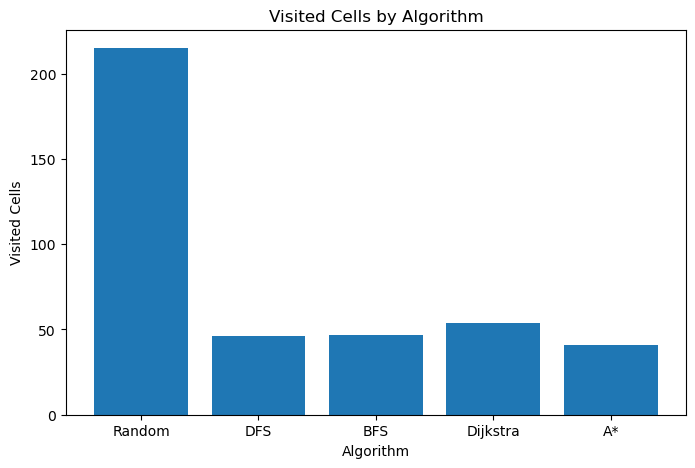

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Algorithm"], results_df["Visited Cells"])
plt.xlabel("Algorithm")
plt.ylabel("Visited Cells")
plt.title("Visited Cells by Algorithm")
plt.show()